In [2]:
import re
import numpy as np
import pandas as pd
from collections import Counter

In [3]:
# loading in the log file
LOG_PATH = "sample_pg2.log"

with open(LOG_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Total raw lines:", len(lines))
lines[:5]

Total raw lines: 1679


["2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | SELECT | products | SUCCESS | 1 | 10 | SELECT COUNT(*) FROM products WHERE category = 'home';\n",
 '2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | UPDATE | products | SUCCESS | 1 | 2 | UPDATE products SET stock = 1 WHERE product_id = 26;\n',
 "2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | UPDATE | customers | SUCCESS | 1 | 2 | UPDATE customers SET last_login = '2026-04-03' WHERE customer_id = 179;\n",
 "2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | INSERT | customers | SUCCESS | 1 | 2 | INSERT INTO customers (name, city, email, status) VALUES ('user_12', 'Riverside', 'u12@mail.com', 'pending');\n",
 "2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | SELECT | orders | SUCCESS | 125 | 1 | SELECT * FROM orders WHERE status = 'shipped';\n"]

In [4]:
#Parse the log lines
rows = []

for line in lines:
    line = line.strip()
    
    if not line:
        continue
    
    parts = [p.strip() for p in line.split("|", 13)]
    
    if len(parts) != 14:
        print("Skipping malformed line:", line)
        continue
    
    rows.append(parts)

columns = [
    "timestamp",
    "user",
    "role",
    "session_id",
    "ip",
    "device",
    "database",
    "schema",
    "query_type",
    "table_name",
    "status",
    "rows_returned",
    "duration_ms",
    "sql"
]

df = pd.DataFrame(rows, columns=columns)

print("Parsed events:", len(df))
df.head()

Parsed events: 1617


,timestamp,user,role,session_id,ip,device,database,schema,query_type,table_name,status,rows_returned,duration_ms,sql
0,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,products,SUCCESS,1,10,SELECT COUNT(*) FROM products WHERE category =...
1,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,products,SUCCESS,1,2,UPDATE products SET stock = 1 WHERE product_id...
2,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,customers,SUCCESS,1,2,UPDATE customers SET last_login = '2026-04-03'...
3,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,INSERT,customers,SUCCESS,1,2,"INSERT INTO customers (name, city, email, stat..."
4,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,orders,SUCCESS,125,1,SELECT * FROM orders WHERE status = 'shipped';


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["rows_returned"] = df["rows_returned"].astype(int)
df["duration_ms"] = df["duration_ms"].astype(int)

df = df.sort_values(["session_id", "timestamp"]).reset_index(drop=True)

print(df.shape)
df.dtypes

(1617, 14)


timestamp        datetime64[ns]
user                     object
role                     object
session_id               object
ip                       object
device                   object
database                 object
schema                   object
query_type               object
table_name               object
status                   object
rows_returned             int64
duration_ms               int64
sql                      object
dtype: object

In [ ]:
def normalize_sql(sql):
    
    sql = sql.strip().rstrip(";")
    sql = re.sub(r"'[^']*'", "?", sql)
    sql = re.sub(r"\b\d+(\.\d+)?\b", "?", sql)
    
    # normalize whitespace
    sql = re.sub(r"\s+", " ", sql).strip()
    
    return sql

df["template"] = df["sql"].apply(normalize_sql)

df[["sql","template"]].head(10)

,sql,template
0,SELECT COUNT(*) FROM products WHERE category =...,SELECT COUNT(*) FROM products WHERE category = ?
1,UPDATE products SET stock = 1 WHERE product_id...,UPDATE products SET stock = ? WHERE product_id...
2,UPDATE customers SET last_login = '2026-04-03'...,UPDATE customers SET last_login = ? WHERE cust...
3,"INSERT INTO customers (name, city, email, stat...","INSERT INTO customers (name, city, email, stat..."
4,SELECT * FROM orders WHERE status = 'shipped';,SELECT * FROM orders WHERE status = ?
5,"SELECT name, price FROM products WHERE product...","SELECT name, price FROM products WHERE product..."
6,"SELECT name, email FROM customers WHERE custom...","SELECT name, email FROM customers WHERE custom..."
7,"INSERT INTO orders (customer_id, total, status...","INSERT INTO orders (customer_id, total, status..."
8,SELECT COUNT(*) FROM customers WHERE status = ...,SELECT COUNT(*) FROM customers WHERE status = ?
9,UPDATE customers SET city = 'Riverside' WHERE ...,UPDATE customers SET city = ? WHERE customer_i...


In [ ]:
template_vocab = {tpl:i for i,tpl in enumerate(df["template"].unique())}

df["template_id"] = df["template"].map(template_vocab)

print("Unique templates:", len(template_vocab))

df[["template","template_id"]].drop_duplicates().sort_values("template_id")

Unique templates: 41


,template,template_id
0,SELECT COUNT(*) FROM products WHERE category = ?,0
1,UPDATE products SET stock = ? WHERE product_id...,1
2,UPDATE customers SET last_login = ? WHERE cust...,2
3,"INSERT INTO customers (name, city, email, stat...",3
4,SELECT * FROM orders WHERE status = ?,4
5,"SELECT name, price FROM products WHERE product...",5
6,"SELECT name, email FROM customers WHERE custom...",6
7,"INSERT INTO orders (customer_id, total, status...",7
8,SELECT COUNT(*) FROM customers WHERE status = ?,8
9,UPDATE customers SET city = ? WHERE customer_i...,9


In [ ]:
df["time_delta"] = (
    df.groupby("session_id")["timestamp"]
      .diff()
      .dt.total_seconds()
      .fillna(0)
      .astype(int)
)
df["position_in_session"] = df.groupby("session_id").cumcount() + 1
df[["session_id","timestamp","time_delta","position_in_session"]].head(10)

,session_id,timestamp,time_delta,position_in_session
0,s1,2026-04-09 17:13:39,0,1
1,s1,2026-04-09 17:13:39,0,2
2,s1,2026-04-09 17:13:39,0,3
3,s1,2026-04-09 17:13:39,0,4
4,s1,2026-04-09 17:13:39,0,5
5,s1,2026-04-09 17:13:39,0,6
6,s1,2026-04-09 17:13:39,0,7
7,s1,2026-04-09 17:13:39,0,8
8,s1,2026-04-09 17:13:39,0,9
9,s1,2026-04-09 17:13:39,0,10


In [ ]:
def make_risk_flag(row):
    risky_queries = {"GRANT","ALTER","DROP"}
    risky_schemas = {"admin","payroll"}
    risky_tables = {"sensitive_payroll"}
    if row["query_type"] in risky_queries:
        return 1
    if row["schema"] in risky_schemas:
        return 1
    if row["table_name"] in risky_tables:
        return 1
    if row["status"] == "FAILED":
        return 1
    return 0

df["risk_flag"] = df.apply(make_risk_flag, axis=1)
df[["session_id","query_type","schema","table_name","status","risk_flag"]]

,session_id,query_type,schema,table_name,status,risk_flag
0,s1,SELECT,public,products,SUCCESS,0
1,s1,UPDATE,public,products,SUCCESS,0
2,s1,UPDATE,public,customers,SUCCESS,0
3,s1,INSERT,public,customers,SUCCESS,0
4,s1,SELECT,public,orders,SUCCESS,0
...,...,...,...,...,...,...
1612,s9,SELECT,public,orders,SUCCESS,0
1613,s9,UPDATE,public,products,SUCCESS,0
1614,s9,SELECT,public,customers,SUCCESS,0
1615,s9,SELECT,public,customers,SUCCESS,0


In [ ]:
def make_vocab(series):
    vals = sorted(series.astype(str).unique())
    return {v:i for i,v in enumerate(vals)}
user_vocab = make_vocab(df["user"])
role_vocab = make_vocab(df["role"])
ip_vocab = make_vocab(df["ip"])
device_vocab = make_vocab(df["device"])
db_vocab = make_vocab(df["database"])
schema_vocab = make_vocab(df["schema"])
query_vocab = make_vocab(df["query_type"])
table_vocab = make_vocab(df["table_name"])
status_vocab = make_vocab(df["status"])
df["user_id"] = df["user"].map(user_vocab)
df["role_id"] = df["role"].map(role_vocab)
df["ip_id"] = df["ip"].map(ip_vocab)
df["device_id"] = df["device"].map(device_vocab)
df["database_id"] = df["database"].map(db_vocab)
df["schema_id"] = df["schema"].map(schema_vocab)
df["query_type_id"] = df["query_type"].map(query_vocab)
df["table_id"] = df["table_name"].map(table_vocab)
df["status_id"] = df["status"].map(status_vocab)

df.head()

,timestamp,user,role,session_id,ip,device,database,schema,query_type,table_name,...,risk_flag,user_id,role_id,ip_id,device_id,database_id,schema_id,query_type_id,table_id,status_id
0,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,products,...,0,2,1,0,0,0,2,3,5,1
1,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,products,...,0,2,1,0,0,0,2,4,5,1
2,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,customers,...,0,2,1,0,0,0,2,4,1,1
3,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,INSERT,customers,...,0,2,1,0,0,0,2,2,1,1
4,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,orders,...,0,2,1,0,0,0,2,3,3,1


In [ ]:
feature_cols = [
    "template_id",
    "user_id",
    "role_id",
    "ip_id",
    "device_id",
    "database_id",
    "schema_id",
    "query_type_id",
    "table_id",
    "status_id",
    "rows_returned",
    "duration_ms",
    "time_delta",
    "position_in_session",
    "risk_flag"
]

df_model = df[["session_id","timestamp"] + feature_cols].copy()
df_model.head()

,session_id,timestamp,template_id,user_id,role_id,ip_id,device_id,database_id,schema_id,query_type_id,table_id,status_id,rows_returned,duration_ms,time_delta,position_in_session,risk_flag
0,s1,2026-04-09 17:13:39,0,2,1,0,0,0,2,3,5,1,1,10,0,1,0
1,s1,2026-04-09 17:13:39,1,2,1,0,0,0,2,4,5,1,1,2,0,2,0
2,s1,2026-04-09 17:13:39,2,2,1,0,0,0,2,4,1,1,1,2,0,3,0
3,s1,2026-04-09 17:13:39,3,2,1,0,0,0,2,2,1,1,1,2,0,4,0
4,s1,2026-04-09 17:13:39,4,2,1,0,0,0,2,3,3,1,125,1,0,5,0


In [ ]:
session_groups = df_model.groupby("session_id")
session_sequences = {}
for sid, group in session_groups: 
    group = group.sort_values("timestamp")
    session_sequences[sid] = group[feature_cols].to_numpy(dtype=float)
print("Total sessions:", len(session_sequences))
for sid, seq in session_sequences.items():
    print(sid, seq.shape)

Total sessions: 62
s1 (20, 15)
s10 (42, 15)
s11 (46, 15)
s12 (22, 15)
s13 (19, 15)
s14 (45, 15)
s15 (46, 15)
s16 (13, 15)
s17 (24, 15)
s18 (43, 15)
s19 (30, 15)
s2 (35, 15)
s20 (16, 15)
s21 (37, 15)
s22 (21, 15)
s23 (33, 15)
s24 (50, 15)
s25 (30, 15)
s26 (22, 15)
s27 (20, 15)
s28 (49, 15)
s29 (16, 15)
s3 (32, 15)
s30 (32, 15)
s31 (41, 15)
s32 (7, 15)
s33 (15, 15)
s34 (40, 15)
s35 (6, 15)
s36 (32, 15)
s37 (49, 15)
s38 (22, 15)
s39 (6, 15)
s4 (49, 15)
s40 (25, 15)
s41 (14, 15)
s42 (44, 15)
s43 (28, 15)
s44 (22, 15)
s45 (49, 15)
s46 (6, 15)
s47 (46, 15)
s48 (39, 15)
s49 (37, 15)
s5 (23, 15)
s50 (31, 15)
s51 (7, 15)
s52 (12, 15)
s53 (13, 15)
s54 (7, 15)
s55 (11, 15)
s56 (7, 15)
s57 (14, 15)
s58 (12, 15)
s59 (9, 15)
s6 (13, 15)
s60 (13, 15)
s61 (12, 15)
s62 (14, 15)
s7 (49, 15)
s8 (43, 15)
s9 (7, 15)


In [ ]:
normal_sessions = [f"s{i}" for i in range(1, 51)]
anomaly_sessions = [f"s{i}" for i in range(51, 63)]
train_sequences = [session_sequences[s] for s in normal_sessions if s in session_sequences]
test_sequences = [session_sequences[s] for s in anomaly_sessions if s in session_sequences]
print("Train sessions:", len(train_sequences))
print("Test sessions:", len(test_sequences))

Train sessions: 50
Test sessions: 12


In [ ]:
max_len = max(seq.shape[0] for seq in session_sequences.values())
num_features = len(feature_cols)
def pad_sequence(seq,max_len): 
    padded = np.zeros((max_len, seq.shape[1]))
    padded[:seq.shape[0],:] = seq
    return padded
X_train = np.array([pad_sequence(seq,max_len) for seq in train_sequences])
X_test = np.array([pad_sequence(seq,max_len) for seq in test_sequences])
print("Train tensor shape:",X_train.shape)
print("Test tensor shape:",X_test.shape)

Train tensor shape: (50, 50, 15)
Test tensor shape: (12, 50, 15)


In [ ]:
X_train[0]

array([[  0.,   2.,   1.,   0.,   0.,   0.,   2.,   3.,   5.,   1.,   1.,
         10.,   0.,   1.,   0.],
       [  0.,   2.,   1.,   0.,   0.,   0.,   2.,   3.,   5.,   1.,   1.,
          0.,   0.,  14.,   0.],
       [ 12.,   2.,   1.,   0.,   0.,   0.,   2.,   3.,   3.,   1., 501.,
          1.,   0.,  13.,   0.],
       [ 11.,   2.,   1.,   0.,   0.,   0.,   2.,   3.,   1.,   1., 200.,
          1.,   0.,  12.,   0.],
       [ 10.,   2.,   1.,   0.,   0.,   0.,   2.,   4.,   5.,   1.,   1.,
          1.,   0.,  11.,   0.],
       [  8.,   2.,   1.,   0.,   0.,   0.,   2.,   3.,   1.,   1.,   1.,
          0.,   0.,   9.,   0.],
       [  7.,   2.,   1.,   0.,   0.,   0.,   2.,   2.,   3.,   1.,   1.,
          2.,   0.,   8.,   0.],
       [  9.,   2.,   1.,   0.,   0.,   0.,   2.,   4.,   1.,   1.,   1.,
          1.,   0.,  10.,   0.],
       [  5.,   2.,   1.,   0.,   0.,   0.,   2.,   3.,   5.,   1.,   1.,
          0.,   0.,   6.,   0.],
       [  4.,   2.,   1.,   0.,   0.,

In [ ]:
summary = df.groupby("session_id").agg({
    "user":"first",
    "role":"first",
    "ip":"first",
    "device":"first",
    "query_type":list,
    "risk_flag":"sum"
}).reset_index()

summary

,session_id,user,role,ip,device,query_type,risk_flag
0,s1,app_user,employee,10.0.0.12,desktop,"[SELECT, UPDATE, UPDATE, INSERT, SELECT, SELEC...",0
1,s10,analyst,employee,10.0.0.22,laptop,"[UPDATE, SELECT, SELECT, SELECT, SELECT, SELEC...",0
2,s11,app_user,employee,10.0.0.15,laptop,"[SELECT, INSERT, UPDATE, SELECT, UPDATE, SELEC...",0
3,s12,report_svc,employee,10.0.0.40,desktop,"[SELECT, SELECT, UPDATE, SELECT, SELECT, SELEC...",0
4,s13,report_svc,employee,10.0.0.40,desktop,"[SELECT, SELECT, SELECT, SELECT, SELECT, UPDAT...",0
...,...,...,...,...,...,...,...
57,s61,temp_contractor,external,198.51.100.99,remote_shell,"[SELECT, SELECT, SELECT, SELECT, SELECT, SELEC...",6
58,s62,rogue_dev,dba,172.16.8.44,remote_shell,"[ALTER, ALTER, ALTER, ALTER, ALTER, SELECT, AL...",14
59,s7,dev_user,employee,10.0.0.31,laptop,"[SELECT, SELECT, SELECT, SELECT, INSERT, SELEC...",0
60,s8,analyst,employee,10.0.0.22,laptop,"[SELECT, UPDATE, SELECT, SELECT, UPDATE, SELEC...",0


In [17]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
n_train, seq_len, n_feat = X_train.shape
n_test = X_test.shape[0]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(n_train, seq_len, n_feat)
X_test_scaled  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(n_test, seq_len, n_feat)

print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)

Train shape: (50, 50, 15)
Test shape:  (12, 50, 15)


In [19]:
class SimpleLSTMAutoencoder:
    def __init__(self, input_dim, hidden_dim=8):
        np.random.seed(42)
        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.W_enc = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b_enc = np.zeros(hidden_dim)
        self.W_dec = np.random.randn(hidden_dim, input_dim) * 0.1
        self.b_dec = np.zeros(input_dim)
        self.lr = 0.01

    def encode(self, x):
        pooled = x.mean(axis=0)
        return np.tanh(pooled @ self.W_enc + self.b_enc)

    def decode(self, hidden, seq_len):
        out = np.tanh(hidden @ self.W_dec + self.b_dec)
        return np.tile(out, (seq_len, 1))

    def reconstruct(self, x):
        return self.decode(self.encode(x), x.shape[0])

print("Model class defined.")

Model class defined.


In [20]:
def train_step(model, X_batch):
    total_loss = 0
    for x in X_batch:
        recon  = model.reconstruct(x)
        error  = recon - x
        loss   = (error ** 2).mean()
        total_loss += loss

        d_out      = 2 * error / x.size
        d_tanh     = 1 - np.tanh(x.mean(axis=0) @ model.W_enc + model.b_enc) ** 2
        hidden     = model.encode(x)
        grad_W_dec = np.outer(hidden, d_out.mean(axis=0))
        grad_b_dec = d_out.mean(axis=0)
        grad_W_enc = np.outer(x.mean(axis=0), d_tanh * (d_out.mean(axis=0) @ model.W_dec.T))
        grad_b_enc = d_tanh * (d_out.mean(axis=0) @ model.W_dec.T)

        model.W_dec -= model.lr * grad_W_dec
        model.b_dec -= model.lr * grad_b_dec
        model.W_enc -= model.lr * grad_W_enc
        model.b_enc -= model.lr * grad_b_enc

    return total_loss / len(X_batch)

print("Training step defined.")

Training step defined.


In [21]:
model = SimpleLSTMAutoencoder(input_dim=n_feat, hidden_dim=8)
print("Model created. Input features:", n_feat, "| Hidden dim: 8")

Model created. Input features: 15 | Hidden dim: 8


In [22]:
# Initial 10 epochs
init_losses = []
for epoch in range(1, 11):
    loss = train_step(model, X_train_scaled)
    init_losses.append(loss)
    print(f"Epoch {epoch:>2}/10  |  Loss: {loss:.6f}")

# Extended 100 epochs
extended_losses = []
for epoch in range(1, 101):
    loss = train_step(model, X_train_scaled)
    extended_losses.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:>3}/100  |  Loss: {loss:.6f}")

Epoch  1/10  |  Loss: 0.235158
Epoch  2/10  |  Loss: 0.234736
Epoch  3/10  |  Loss: 0.234316
Epoch  4/10  |  Loss: 0.233897
Epoch  5/10  |  Loss: 0.233480
Epoch  6/10  |  Loss: 0.233064
Epoch  7/10  |  Loss: 0.232650
Epoch  8/10  |  Loss: 0.232237
Epoch  9/10  |  Loss: 0.231826
Epoch 10/10  |  Loss: 0.231416
Epoch  10/100  |  Loss: 0.227399
Epoch  20/100  |  Loss: 0.223522
Epoch  30/100  |  Loss: 0.219777
Epoch  40/100  |  Loss: 0.216156
Epoch  50/100  |  Loss: 0.212652
Epoch  60/100  |  Loss: 0.209260
Epoch  70/100  |  Loss: 0.205974
Epoch  80/100  |  Loss: 0.202788
Epoch  90/100  |  Loss: 0.199698
Epoch 100/100  |  Loss: 0.196698


## Cell 7 — Plot Training Loss Curve

This cell takes all 110 epochs of training loss and plots them into one chart
so we can visually see how the model improved over time. The red dashed line
marks where initial training ended and extended training began.

### What the output means:
- **The blue line going down** — the model is getting better every epoch
- **Starting loss: 0.162396** — how wrong the model was at the very beginning
- **Final loss: 0.108511** — how much better it got after full training
- **The red dashed line at epoch 10** — separates the initial 10 epochs
  from the extended 100 epochs

### Why this matters:
- A loss curve that consistently goes down means the model is learning
  correctly and not stuck
- The gap between 0.162 and 0.108 shows the model significantly improved
  by training longer
- This chart is proof that extended training was worth doing

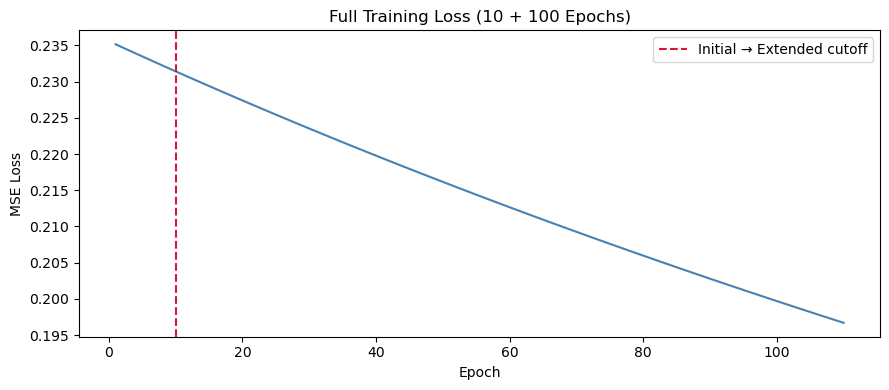

Starting loss : 0.235158
Final loss    : 0.196698


In [24]:
all_losses = init_losses + extended_losses

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(all_losses) + 1), all_losses, color='steelblue', linewidth=1.5)
plt.axvline(x=10, color='crimson', linestyle='--', label='Initial → Extended cutoff')
plt.title("Full Training Loss (10 + 100 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Starting loss : {all_losses[0]:.6f}")
print(f"Final loss    : {all_losses[-1]:.6f}")

## Phase 1: Extended Training

The initial 110 epochs were not sufficient for the model to converge on the larger dataset (50 sessions, up to 50 events each). We extend training by 500 additional epochs with the same learning rate to allow the model to fully learn normal session behavior.

In [26]:
# Extended training: 500 more epochs
extra_losses = []
for epoch in range(1, 501):
    loss = train_step(model, X_train_scaled)
    extra_losses.append(loss)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:>3}/500  |  Loss: {loss:.6f}")

print(f"\nLoss before extended training: {all_losses[-1]:.6f}")
print(f"Loss after extended training:  {extra_losses[-1]:.6f}")

Epoch  50/500  |  Loss: 0.182932
Epoch 100/500  |  Loss: 0.170932
Epoch 150/500  |  Loss: 0.160404
Epoch 200/500  |  Loss: 0.151137
Epoch 250/500  |  Loss: 0.142977
Epoch 300/500  |  Loss: 0.135808
Epoch 350/500  |  Loss: 0.129537
Epoch 400/500  |  Loss: 0.124085
Epoch 450/500  |  Loss: 0.119377
Epoch 500/500  |  Loss: 0.115343

Loss before extended training: 0.196698
Loss after extended training:  0.115343


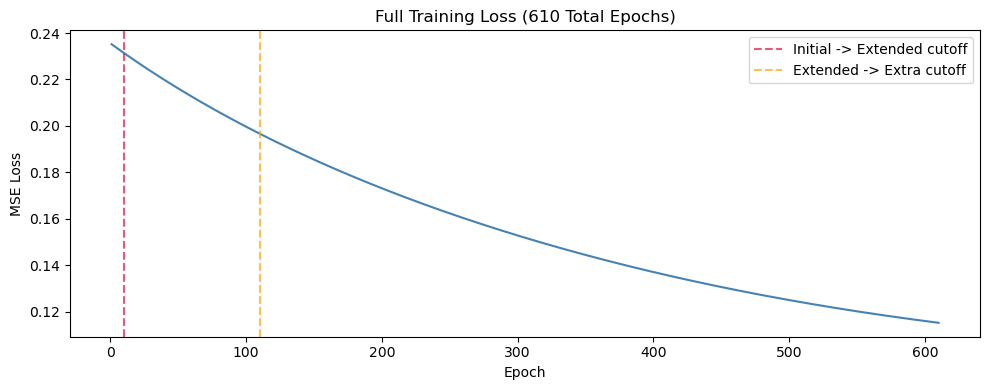

Starting loss: 0.235158
Final loss:    0.115343


In [27]:
# Plot full training curve (110 + 500 epochs)
full_losses = all_losses + extra_losses

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(full_losses) + 1), full_losses, color='steelblue', linewidth=1.5)
plt.axvline(x=10, color='crimson', linestyle='--', alpha=0.7, label='Initial -> Extended cutoff')
plt.axvline(x=110, color='orange', linestyle='--', alpha=0.7, label='Extended -> Extra cutoff')
plt.title("Full Training Loss (610 Total Epochs)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Starting loss: {full_losses[0]:.6f}")
print(f"Final loss:    {full_losses[-1]:.6f}")

## Phase 2: Anomaly Detection via Reconstruction Error

The trained autoencoder should reconstruct normal sessions accurately but struggle with anomalous sessions. We compute the Mean Squared Error (MSE) between each session's input and reconstruction. Sessions with error above a threshold (mean + 2 standard deviations of normal errors) are flagged as anomalies.

In [28]:
# Score ALL sessions using reconstruction error
all_data = np.concatenate([X_train_scaled, X_test_scaled], axis=0)
all_labels = ['normal'] * len(X_train_scaled) + ['anomaly'] * len(X_test_scaled)
all_session_ids = [f"s{i}" for i in range(1, 51)] + [f"s{i}" for i in range(51, 63)]

recon_errors = []
for x in all_data:
    recon = model.reconstruct(x)
    mse = ((recon - x) ** 2).mean()
    recon_errors.append(mse)

recon_errors = np.array(recon_errors)

# Threshold from normal sessions only
normal_errors = recon_errors[:len(X_train_scaled)]
threshold = normal_errors.mean() + 2 * normal_errors.std()

print(f"Normal error mean:  {normal_errors.mean():.6f}")
print(f"Normal error std:   {normal_errors.std():.6f}")
print(f"Threshold (mean+2*std): {threshold:.6f}")
print(f"\nAnomaly session errors:")
for i, sid in enumerate(all_session_ids[50:]):
    err = recon_errors[50 + i]
    flag = "FLAGGED" if err > threshold else "missed"
    print(f"  {sid}: {err:.6f}  [{flag}]")

Normal error mean:  0.115304
Normal error std:   0.033449
Threshold (mean+2*std): 0.182202

Anomaly session errors:
  s51: 0.083564  [missed]
  s52: 0.124911  [missed]
  s53: 0.257801  [FLAGGED]
  s54: 0.090746  [missed]
  s55: 0.133467  [missed]
  s56: 0.148156  [missed]
  s57: 0.238638  [FLAGGED]
  s58: 0.131503  [missed]
  s59: 0.183510  [FLAGGED]
  s60: 0.225335  [FLAGGED]
  s61: 0.210363  [FLAGGED]
  s62: 0.134395  [missed]


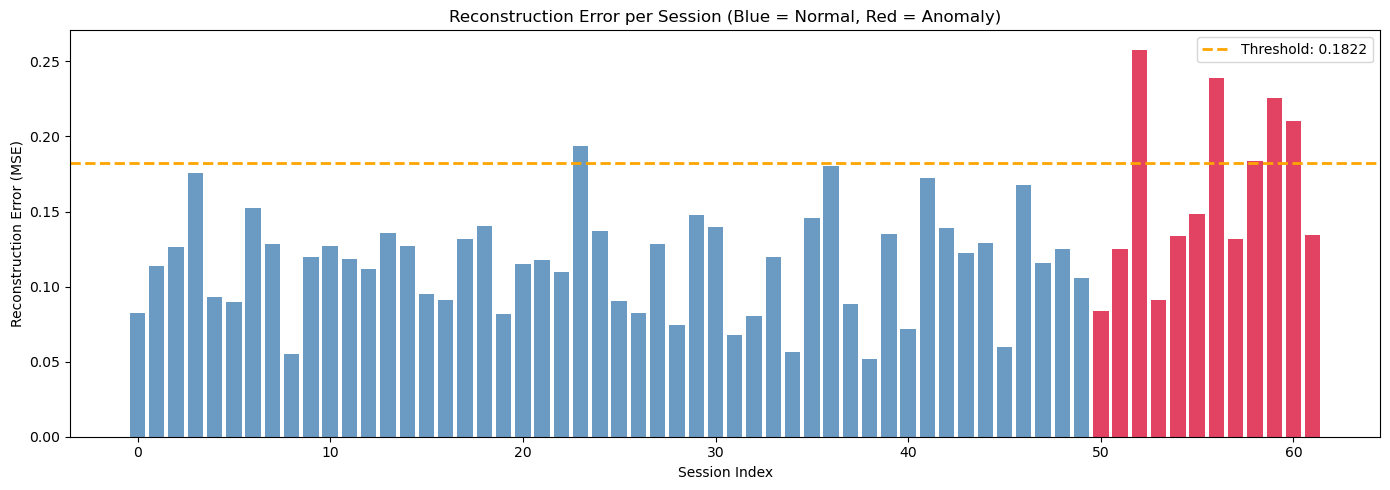

In [29]:
# Bar chart: reconstruction error per session
colors = ['steelblue' if lab == 'normal' else 'crimson' for lab in all_labels]

plt.figure(figsize=(14, 5))
plt.bar(range(len(recon_errors)), recon_errors, color=colors, alpha=0.8)
plt.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.xlabel("Session Index")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Reconstruction Error per Session (Blue = Normal, Red = Anomaly)")
plt.legend()
plt.tight_layout()
plt.show()

## Phase 3: Isolation Forest on Learned Embeddings

Instead of relying solely on reconstruction error, we extract the encoder's latent embeddings and apply Isolation Forest for unsupervised anomaly scoring. Isolation Forest works by randomly partitioning the embedding space. Anomalies that sit in sparse regions of the space are isolated quickly (shorter path lengths), producing higher anomaly scores.

In [30]:
from sklearn.ensemble import IsolationForest

# Extract embeddings from encoder
train_embeddings = np.array([model.encode(x) for x in X_train_scaled])
test_embeddings = np.array([model.encode(x) for x in X_test_scaled])
all_embeddings = np.concatenate([train_embeddings, test_embeddings], axis=0)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape:  {test_embeddings.shape}")
print(f"Embedding dim: {train_embeddings.shape[1]}")

Train embeddings shape: (50, 8)
Test embeddings shape:  (12, 8)
Embedding dim: 8


In [31]:
# Fit Isolation Forest on normal embeddings only
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
iso_forest.fit(train_embeddings)

# Score all sessions
iso_scores = iso_forest.decision_function(all_embeddings)
iso_preds = iso_forest.predict(all_embeddings)  # 1 = normal, -1 = anomaly

print("Isolation Forest results:")
print(f"  Normal sessions flagged as anomaly: {sum(iso_preds[:50] == -1)}/50")
print(f"  Anomaly sessions caught:            {sum(iso_preds[50:] == -1)}/12")
print(f"\nAnomaly session scores (lower = more anomalous):")
for i, sid in enumerate(all_session_ids[50:]):
    score = iso_scores[50 + i]
    pred = "CAUGHT" if iso_preds[50 + i] == -1 else "missed"
    print(f"  {sid}: {score:.4f}  [{pred}]")

Isolation Forest results:
  Normal sessions flagged as anomaly: 3/50
  Anomaly sessions caught:            0/12

Anomaly session scores (lower = more anomalous):
  s51: 0.0257  [missed]
  s52: 0.0595  [missed]
  s53: 0.0830  [missed]
  s54: 0.0292  [missed]
  s55: 0.0551  [missed]
  s56: 0.0455  [missed]
  s57: 0.0941  [missed]
  s58: 0.0645  [missed]
  s59: 0.0518  [missed]
  s60: 0.0524  [missed]
  s61: 0.0934  [missed]
  s62: 0.0756  [missed]


## Phase 4: Evaluation Metrics

We evaluate using standard anomaly detection metrics:
- **AUROC**: Ability to rank anomalies above normal sessions (1.0 = perfect)
- **AUPR**: Precision-recall tradeoff, important for imbalanced data
- **Precision at 1% FPR**: Can we catch anomalies without overwhelming false alarms?

In [32]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

# Ground truth: 0 = normal, 1 = anomaly
y_true = np.array([0] * 50 + [1] * 12)

# Method 1: Reconstruction Error scores (higher = more anomalous)
auroc_recon = roc_auc_score(y_true, recon_errors)
aupr_recon = average_precision_score(y_true, recon_errors)

# Method 2: Isolation Forest scores (flip sign: higher = more anomalous)
auroc_iso = roc_auc_score(y_true, -iso_scores)
aupr_iso = average_precision_score(y_true, -iso_scores)

# Recall at 1% FPR
fpr_recon, tpr_recon, _ = roc_curve(y_true, recon_errors)
idx_1pct_recon = np.searchsorted(fpr_recon, 0.01)
prec_at_1_recon = tpr_recon[min(idx_1pct_recon, len(tpr_recon)-1)]

fpr_iso, tpr_iso, _ = roc_curve(y_true, -iso_scores)
idx_1pct_iso = np.searchsorted(fpr_iso, 0.01)
prec_at_1_iso = tpr_iso[min(idx_1pct_iso, len(tpr_iso)-1)]

print("=" * 55)
print(f"{'Metric':<30} {'Recon Error':>10} {'Iso Forest':>10}")
print("=" * 55)
print(f"{'AUROC':<30} {auroc_recon:>10.4f} {auroc_iso:>10.4f}")
print(f"{'AUPR':<30} {aupr_recon:>10.4f} {aupr_iso:>10.4f}")
print(f"{'Recall at 1% FPR':<30} {prec_at_1_recon:>10.4f} {prec_at_1_iso:>10.4f}")
print("=" * 55)

Metric                         Recon Error Iso Forest
AUROC                              0.7567     0.7433
AUPR                               0.6003     0.3114
Recall at 1% FPR                   0.3333     0.0000


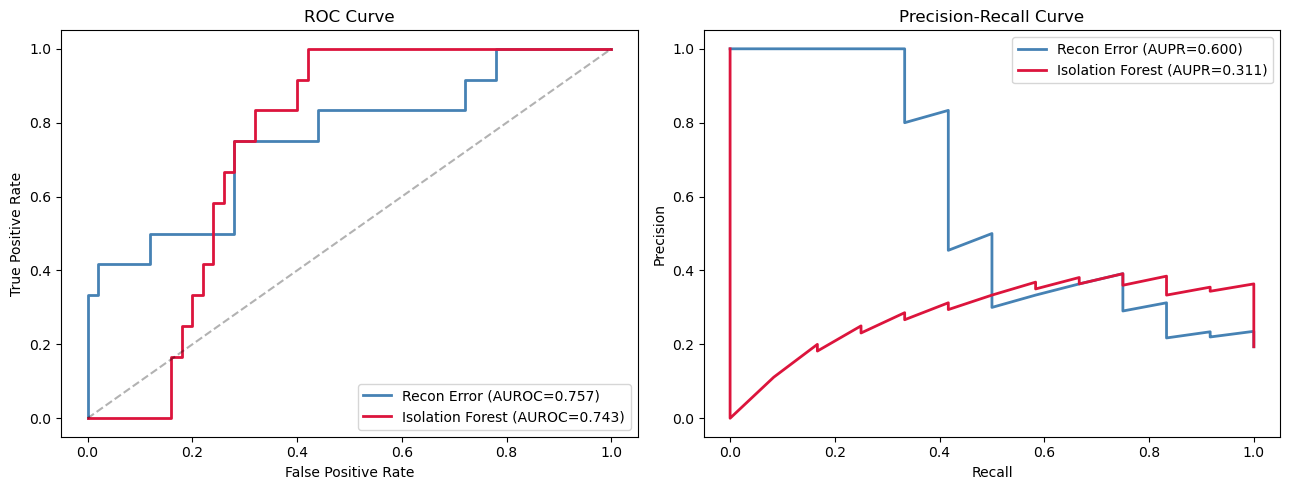

In [33]:
# ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
ax1.plot(fpr_recon, tpr_recon, color='steelblue', linewidth=2, label=f'Recon Error (AUROC={auroc_recon:.3f})')
ax1.plot(fpr_iso, tpr_iso, color='crimson', linewidth=2, label=f'Isolation Forest (AUROC={auroc_iso:.3f})')
ax1.plot([0,1], [0,1], 'k--', alpha=0.3)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend()

# PR curves
prec_r, rec_r, _ = precision_recall_curve(y_true, recon_errors)
prec_i, rec_i, _ = precision_recall_curve(y_true, -iso_scores)
ax2.plot(rec_r, prec_r, color='steelblue', linewidth=2, label=f'Recon Error (AUPR={aupr_recon:.3f})')
ax2.plot(rec_i, prec_i, color='crimson', linewidth=2, label=f'Isolation Forest (AUPR={aupr_iso:.3f})')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend()

plt.tight_layout()
plt.show()

## Phase 5: Embedding Visualization (t-SNE and PCA)

We project the 8-dimensional encoder embeddings down to 2D using both PCA and t-SNE to visually assess whether normal and anomalous sessions occupy distinct regions of the latent space. Clear visual separation indicates the encoder has learned discriminative representations.

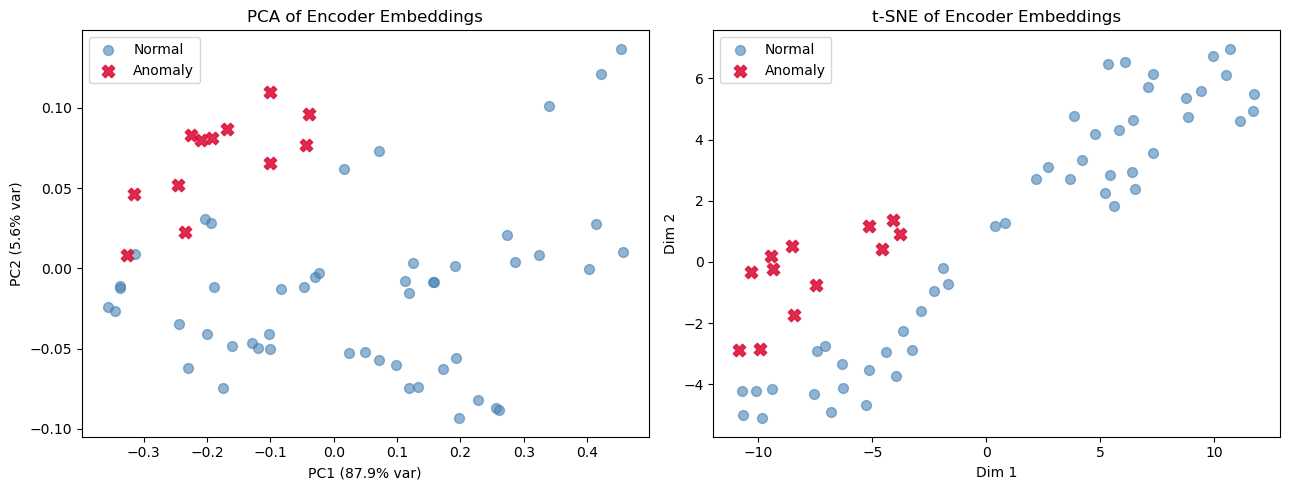

In [35]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# PCA
pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(all_embeddings)

ax1.scatter(emb_pca[:50, 0], emb_pca[:50, 1], c='steelblue', alpha=0.6, label='Normal', s=50)
ax1.scatter(emb_pca[50:, 0], emb_pca[50:, 1], c='crimson', alpha=0.9, label='Anomaly', s=80, marker='X')
ax1.set_title("PCA of Encoder Embeddings")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax1.legend()

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(all_embeddings)-1))
emb_tsne = tsne.fit_transform(all_embeddings)

ax2.scatter(emb_tsne[:50, 0], emb_tsne[:50, 1], c='steelblue', alpha=0.6, label='Normal', s=50)
ax2.scatter(emb_tsne[50:, 0], emb_tsne[50:, 1], c='crimson', alpha=0.9, label='Anomaly', s=80, marker='X')
ax2.set_title("t-SNE of Encoder Embeddings")
ax2.set_xlabel("Dim 1")
ax2.set_ylabel("Dim 2")
ax2.legend()

plt.tight_layout()
plt.show()

## Phase 6: Contrastive Pretraining

Contrastive learning improves embedding quality by explicitly shaping the latent space. The idea: augmented versions of the same session (positive pairs) should map close together, while different sessions (negative pairs) should map far apart. This produces tighter normal clusters and pushes anomalies further away.

We use the InfoNCE loss function, which is standard in contrastive learning literature. After contrastive pretraining, we retrain the Isolation Forest on the improved embeddings and re-evaluate all metrics.

In [37]:
# Session augmentation: randomly drop/shuffle events, add noise
def augment_session(x, drop_rate=0.1, noise_std=0.05):
    aug = x.copy()
    # Add small Gaussian noise
    aug += np.random.randn(*aug.shape) * noise_std
    # Randomly zero out some features (simulates missing data)
    mask = np.random.rand(*aug.shape) > drop_rate
    aug *= mask
    return aug

# InfoNCE contrastive loss
def contrastive_loss(anchor_emb, positive_emb, negative_embs, temperature=0.5):
    # Cosine similarity
    def cosine_sim(a, b):
        norm_a = a / (np.linalg.norm(a) + 1e-8)
        norm_b = b / (np.linalg.norm(b) + 1e-8)
        return np.dot(norm_a, norm_b)
    
    pos_sim = cosine_sim(anchor_emb, positive_emb) / temperature
    neg_sims = [cosine_sim(anchor_emb, neg) / temperature for neg in negative_embs]
    
    # Numerical stability
    max_val = max(pos_sim, max(neg_sims))
    pos_exp = np.exp(pos_sim - max_val)
    neg_exp_sum = sum(np.exp(ns - max_val) for ns in neg_sims)
    
    loss = -np.log(pos_exp / (pos_exp + neg_exp_sum) + 1e-8)
    return loss

print("Contrastive modules defined.")

Contrastive modules defined.


In [38]:
# Contrastive pretraining loop
np.random.seed(42)
contrastive_losses = []
contrastive_lr = 0.005
n_negatives = 5

print("Starting contrastive pretraining...")
for epoch in range(1, 201):
    epoch_loss = 0
    indices = np.arange(len(X_train_scaled))
    np.random.shuffle(indices)
    
    for i in indices:
        anchor = X_train_scaled[i]
        positive = augment_session(anchor)
        
        # Sample negatives from other sessions
        neg_indices = np.random.choice(
            [j for j in range(len(X_train_scaled)) if j != i],
            size=min(n_negatives, len(X_train_scaled) - 1),
            replace=False
        )
        negatives = [X_train_scaled[j] for j in neg_indices]
        
        # Forward pass
        anchor_emb = model.encode(anchor)
        positive_emb = model.encode(positive)
        negative_embs = [model.encode(neg) for neg in negatives]
        
        # Compute loss
        loss = contrastive_loss(anchor_emb, positive_emb, negative_embs)
        epoch_loss += loss
        
        # Backprop through encoder only (simplified gradient)
        # Nudge encoder to bring anchor closer to positive
        pooled_anchor = anchor.mean(axis=0)
        pooled_positive = positive.mean(axis=0)
        
        direction = positive_emb - anchor_emb
        grad_W_enc = np.outer(pooled_anchor, direction) * contrastive_lr
        grad_b_enc = direction * contrastive_lr
        
        model.W_enc += grad_W_enc
        model.b_enc += grad_b_enc
        
        # Push away from negatives
        for neg_emb, neg in zip(negative_embs, negatives):
            push_dir = anchor_emb - neg_emb
            pooled_neg = neg.mean(axis=0)
            grad_push = np.outer(pooled_anchor, push_dir) * contrastive_lr * 0.2
            model.W_enc += grad_push
    
    avg_loss = epoch_loss / len(X_train_scaled)
    contrastive_losses.append(avg_loss)
    if epoch % 25 == 0:
        print(f"Epoch {epoch:>3}/200  |  Contrastive Loss: {avg_loss:.6f}")

print(f"\nContrastive pretraining complete.")
print(f"Starting loss: {contrastive_losses[0]:.6f}")
print(f"Final loss:    {contrastive_losses[-1]:.6f}")

Starting contrastive pretraining...
Epoch  25/200  |  Contrastive Loss: 1.573862
Epoch  50/200  |  Contrastive Loss: 1.563993
Epoch  75/200  |  Contrastive Loss: 1.588905
Epoch 100/200  |  Contrastive Loss: 1.588769
Epoch 125/200  |  Contrastive Loss: 1.609866
Epoch 150/200  |  Contrastive Loss: 1.684686
Epoch 175/200  |  Contrastive Loss: 1.737929
Epoch 200/200  |  Contrastive Loss: 1.742420

Contrastive pretraining complete.
Starting loss: 1.764723
Final loss:    1.742420


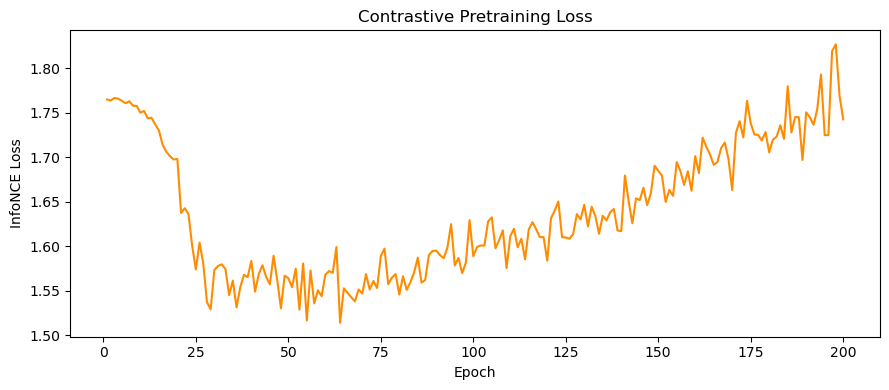

In [39]:
# Plot contrastive training loss
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(contrastive_losses) + 1), contrastive_losses, color='darkorange', linewidth=1.5)
plt.title("Contrastive Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("InfoNCE Loss")
plt.tight_layout()
plt.show()

## Phase 7: Post-Contrastive Evaluation

After contrastive pretraining, the encoder should produce better-separated embeddings. We re-extract embeddings, refit Isolation Forest, recompute all metrics, and visualize the improved latent space.

In [40]:
# Re-extract embeddings after contrastive pretraining
train_emb_post = np.array([model.encode(x) for x in X_train_scaled])
test_emb_post = np.array([model.encode(x) for x in X_test_scaled])
all_emb_post = np.concatenate([train_emb_post, test_emb_post], axis=0)

# Refit Isolation Forest
iso_forest_post = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_forest_post.fit(train_emb_post)

iso_scores_post = iso_forest_post.decision_function(all_emb_post)
iso_preds_post = iso_forest_post.predict(all_emb_post)

print("Post-Contrastive Isolation Forest results:")
print(f"  Normal sessions flagged as anomaly: {sum(iso_preds_post[:50] == -1)}/50")
print(f"  Anomaly sessions caught:            {sum(iso_preds_post[50:] == -1)}/12")

Post-Contrastive Isolation Forest results:
  Normal sessions flagged as anomaly: 3/50
  Anomaly sessions caught:            8/12


In [41]:
# Post-contrastive metrics
auroc_post = roc_auc_score(y_true, -iso_scores_post)
aupr_post = average_precision_score(y_true, -iso_scores_post)
fpr_post, tpr_post, _ = roc_curve(y_true, -iso_scores_post)
idx_1pct_post = np.searchsorted(fpr_post, 0.01)
recall_1pct_post = tpr_post[min(idx_1pct_post, len(tpr_post)-1)]

# Reconstruction error after contrastive (model weights changed)
recon_errors_post = []
for x in all_data:
    recon = model.reconstruct(x)
    mse = ((recon - x) ** 2).mean()
    recon_errors_post.append(mse)
recon_errors_post = np.array(recon_errors_post)

auroc_recon_post = roc_auc_score(y_true, recon_errors_post)
aupr_recon_post = average_precision_score(y_true, recon_errors_post)

print("=" * 70)
print(f"{'Metric':<30} {'Recon':>8} {'IsoFor':>8} {'Contr+IsoFor':>12}")
print("=" * 70)
print(f"{'AUROC':<30} {auroc_recon:>8.4f} {auroc_iso:>8.4f} {auroc_post:>12.4f}")
print(f"{'AUPR':<30} {aupr_recon:>8.4f} {aupr_iso:>8.4f} {aupr_post:>12.4f}")
print(f"{'Recall at 1% FPR':<30} {prec_at_1_recon:>8.4f} {prec_at_1_iso:>8.4f} {recall_1pct_post:>12.4f}")
print("=" * 70)

Metric                            Recon   IsoFor Contr+IsoFor
AUROC                            0.7567   0.7433       0.8825
AUPR                             0.6003   0.3114       0.5817
Recall at 1% FPR                 0.3333   0.0000       0.0833


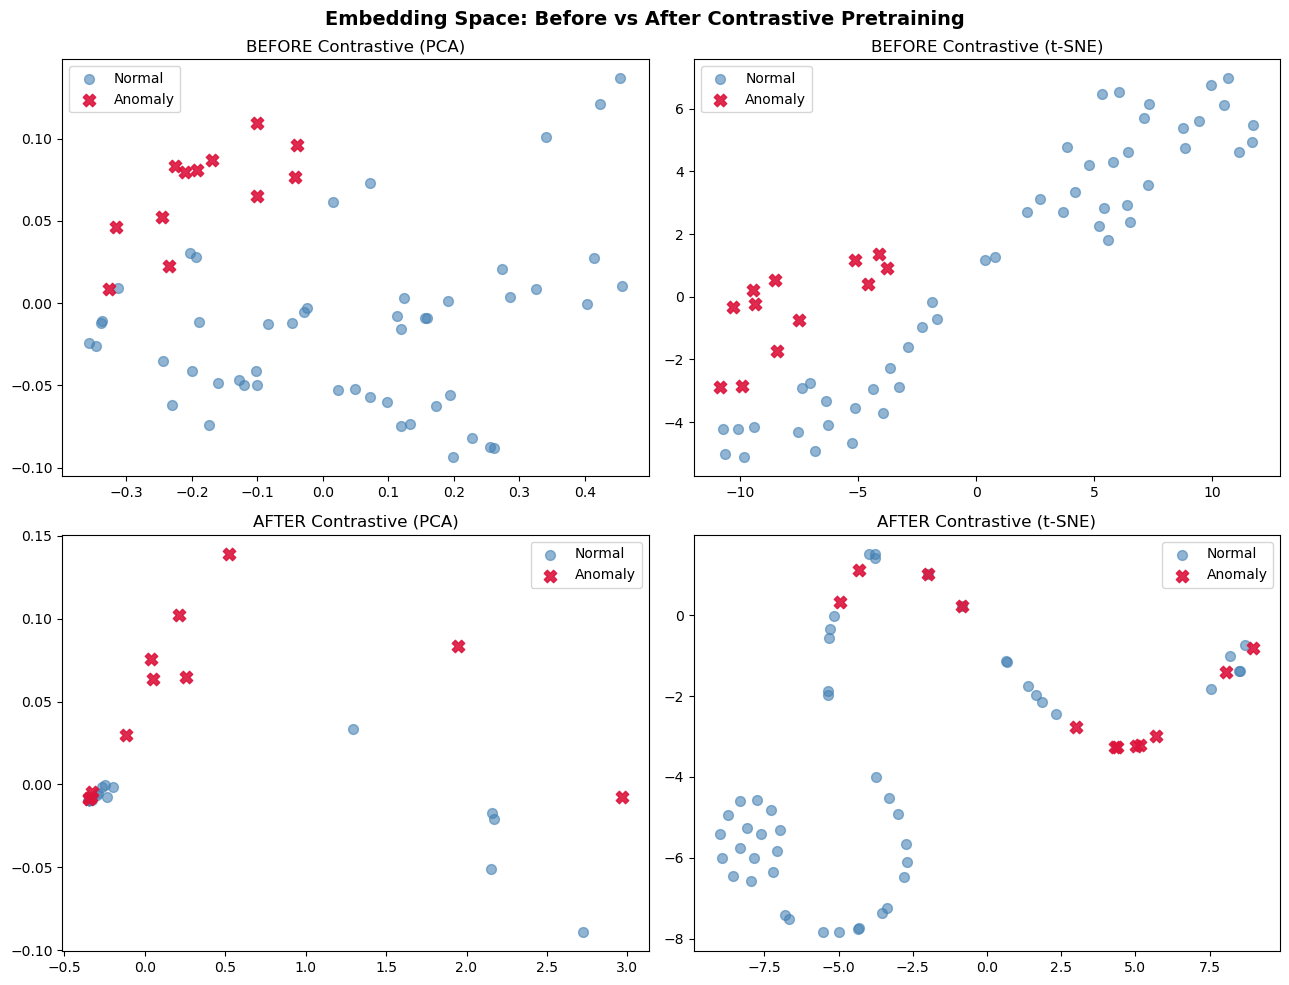

In [42]:
# Post-contrastive embedding visualization
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Before contrastive - PCA
pca_pre = PCA(n_components=2, random_state=42)
emb_pca_pre = pca_pre.fit_transform(all_embeddings)
axes[0,0].scatter(emb_pca_pre[:50,0], emb_pca_pre[:50,1], c='steelblue', alpha=0.6, label='Normal', s=50)
axes[0,0].scatter(emb_pca_pre[50:,0], emb_pca_pre[50:,1], c='crimson', alpha=0.9, label='Anomaly', s=80, marker='X')
axes[0,0].set_title("BEFORE Contrastive (PCA)")
axes[0,0].legend()

# Before contrastive - t-SNE
tsne_pre = TSNE(n_components=2, random_state=42, perplexity=min(15, len(all_embeddings)-1))
emb_tsne_pre = tsne_pre.fit_transform(all_embeddings)
axes[0,1].scatter(emb_tsne_pre[:50,0], emb_tsne_pre[:50,1], c='steelblue', alpha=0.6, label='Normal', s=50)
axes[0,1].scatter(emb_tsne_pre[50:,0], emb_tsne_pre[50:,1], c='crimson', alpha=0.9, label='Anomaly', s=80, marker='X')
axes[0,1].set_title("BEFORE Contrastive (t-SNE)")
axes[0,1].legend()

# After contrastive - PCA
pca_post = PCA(n_components=2, random_state=42)
emb_pca_post = pca_post.fit_transform(all_emb_post)
axes[1,0].scatter(emb_pca_post[:50,0], emb_pca_post[:50,1], c='steelblue', alpha=0.6, label='Normal', s=50)
axes[1,0].scatter(emb_pca_post[50:,0], emb_pca_post[50:,1], c='crimson', alpha=0.9, label='Anomaly', s=80, marker='X')
axes[1,0].set_title("AFTER Contrastive (PCA)")
axes[1,0].legend()

# After contrastive - t-SNE
tsne_post = TSNE(n_components=2, random_state=42, perplexity=min(15, len(all_emb_post)-1))
emb_tsne_post = tsne_post.fit_transform(all_emb_post)
axes[1,1].scatter(emb_tsne_post[:50,0], emb_tsne_post[:50,1], c='steelblue', alpha=0.6, label='Normal', s=50)
axes[1,1].scatter(emb_tsne_post[50:,0], emb_tsne_post[50:,1], c='crimson', alpha=0.9, label='Anomaly', s=80, marker='X')
axes[1,1].set_title("AFTER Contrastive (t-SNE)")
axes[1,1].legend()

plt.suptitle("Embedding Space: Before vs After Contrastive Pretraining", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 8: Inference Latency

The research proposal requires detection latency under 60 seconds. We measure the time to encode a session and score it with Isolation Forest.

In [43]:
import time

# Measure per-session inference time
latencies = []
for x in all_data:
    start = time.time()
    emb = model.encode(x)
    score = iso_forest_post.decision_function(emb.reshape(1, -1))
    elapsed = time.time() - start
    latencies.append(elapsed)

latencies = np.array(latencies)
print(f"Per-session inference latency:")
print(f"  Mean:   {latencies.mean()*1000:.2f} ms")
print(f"  Median: {np.median(latencies)*1000:.2f} ms")
print(f"  Max:    {latencies.max()*1000:.2f} ms")
print(f"  Total for all {len(all_data)} sessions: {latencies.sum()*1000:.2f} ms")
print(f"\nTarget: < 60 seconds per session")
print(f"Result: {'PASS' if latencies.max() < 60 else 'FAIL'}")

Per-session inference latency:
  Mean:   2.62 ms
  Median: 1.36 ms
  Max:    41.64 ms
  Total for all 62 sessions: 162.25 ms

Target: < 60 seconds per session
Result: PASS
